In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../data/2019_oct_dec.csv")

In [3]:
columns = ["event_time", "event_type", "product_id","category_id", "price", "user_id", "user_session"]
df = df[columns]

In [4]:
df["event_time"] = pd.to_datetime(df["event_time"])
df["year"] = df["event_time"].dt.year
df["month"] = df["event_time"].dt.month
df["day"] = df["event_time"].dt.day
df["hour"] = df["event_time"].dt.hour

In [5]:
df_oct = df[df["month"] == 10]
df_nov = df[df["month"] == 11]
df_dec = df[df["month"] == 12]

Найдём конверсию продаж за 3 месяца

In [6]:
event_types = ["view", "cart", "remove_from_cart", "purchase"]

In [7]:
events_oct = [df_oct[df_oct["event_type"]==i]["user_id"].nunique()  for i in event_types]
events_nov = [df_nov[df_nov["event_type"]==i]["user_id"].nunique()  for i in event_types]
events_dec = [df_dec[df_dec["event_type"]==i]["user_id"].nunique() for i in event_types]

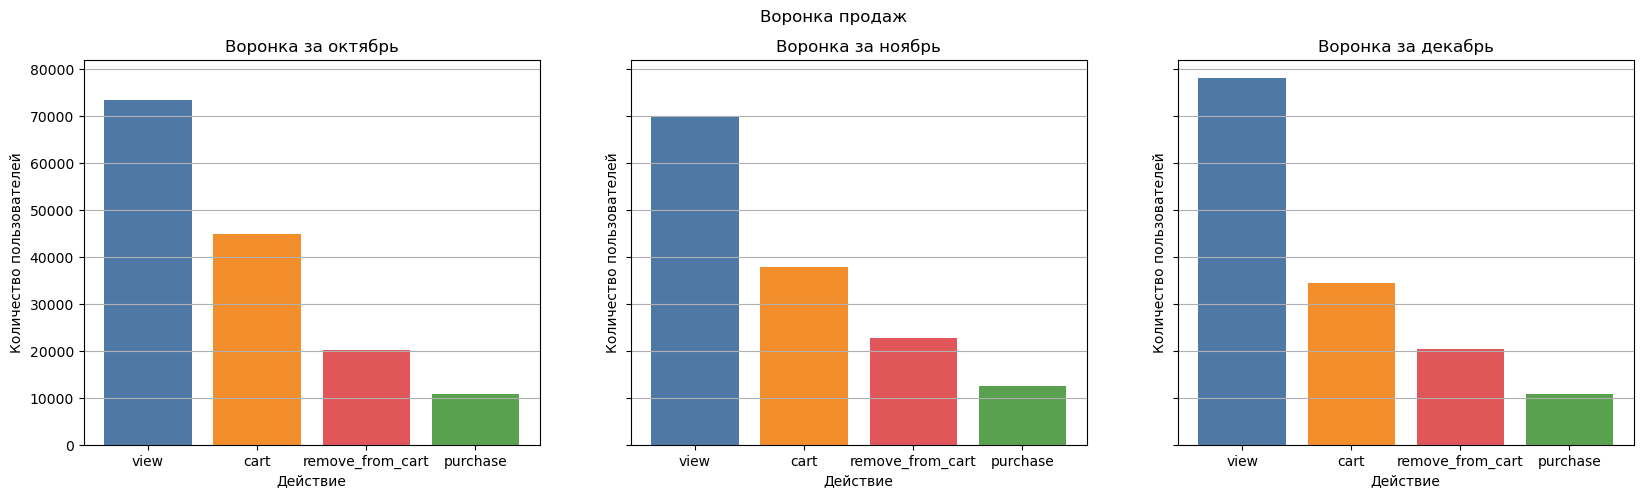

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey = True)
colors = ["#4E79A7", "#F28E2B", "#E15759", "#59A14F"]

fig.suptitle("Воронка продаж")

axes[0].bar(event_types, events_oct, color = colors)
axes[0].set_title("Воронка за октябрь")
axes[0].set_xlabel("Действие")
axes[0].set_ylabel("Количество пользователей")
axes[0].yaxis.grid()

axes[1].bar(event_types, events_nov, color = colors)
axes[1].set_title("Воронка за ноябрь")
axes[1].set_xlabel("Действие")
axes[1].set_ylabel("Количество пользователей")
axes[1].yaxis.grid()

axes[2].bar(event_types, events_dec, color = colors)
axes[2].set_title("Воронка за декабрь")
axes[2].set_xlabel("Действие")
axes[2].set_ylabel("Количество пользователей")
axes[2].yaxis.grid()

fig.savefig("../images/sales_funnel.png")

In [25]:
conv_to_cart_oct = events_oct[1] / events_oct[0] * 100
conv_to_purchase_oct = events_oct[3] / events_oct[0] * 100
print("October conversion %")
print("----------------------------------------")
print(f"View → Cart: {conv_to_cart_oct:.1f}%")
print(f"View → Purchase: {conv_to_purchase_oct:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_oct = events_oct[2] / events_oct[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_oct:.1f}%")

October conversion %
----------------------------------------
View → Cart: 61.1%
View → Purchase: 14.6%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 45.1%


In [27]:
conv_to_cart_nov= events_nov[1] / events_nov[0] * 100
conv_to_purchase_nov = events_nov[3] / events_nov[0] * 100
print("November conversion %")
print("----------------------------------------")
print(f"View → Cart: {conv_to_cart_nov:.1f}%")
print(f"View → Purchase: {conv_to_purchase_nov:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_nov = events_nov[2] / events_nov[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_nov:.1f}%")

November conversion %
----------------------------------------
View → Cart: 54.0%
View → Purchase: 18.0%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 60.3%


In [26]:
conv_to_cart_dec = events_dec[1] / events_dec[0] * 100
conv_to_purchase_dec = events_dec[3] / events_dec[0] * 100
print("December conversion %")
print("-----------------------------------------------")
print(f"View → Cart: {conv_to_cart_dec:.1f}%")
print(f"View → Purchase: {conv_to_purchase_dec:.1f}%")
print("----------------------------------------")
print("Uncomplete purchase:")
conv_to_cart_dec = events_dec[2] / events_dec[1] * 100
print(f"Cart → Remove from cart: {conv_to_cart_dec:.1f}%")

December conversion %
-----------------------------------------------
View → Cart: 44.0%
View → Purchase: 13.8%
----------------------------------------
Uncomplete purchase:
Cart → Remove from cart: 59.0%


Узнаем средний чек за 3 месяца и отдельно за каждый месяц

In [69]:
sum_purchase = df[df["event_type"] == "purchase"]["price"].sum()
count_purchase = df[df["event_type"] == "purchase"].size
print(f"Средний чек за 3 месяца: {sum_purchase / count_purchase:.2f}$")

print("---------------------------------")

sum_purchase_oct = df[(df["event_type"] == "purchase") & (df["month"] == 10)]["price"].sum()
count_purchase_oct = df[(df["event_type"] == "purchase") & (df["month"] == 10)].size
print(f"Средний чек за октябрь: {sum_purchase_oct / count_purchase_oct:.2f}$")

sum_purchase_nov = df[(df["event_type"] == "purchase") & (df["month"] == 11)]["price"].sum()
count_purchase_nov = df[(df["event_type"] == "purchase") & (df["month"] == 11)].size
print(f"Средний чек за ноябрь: {sum_purchase_nov / count_purchase_nov:.2f}$")

sum_purchase_dec = df[(df["event_type"] == "purchase") & (df["month"] == 12)]["price"].sum()
count_purchase_dec = df[(df["event_type"] == "purchase") & (df["month"] == 12)].size
print(f"Средний чек за декабрь: {sum_purchase_dec / count_purchase_dec:.2f}$")


Средний чек за 3 месяца: 0.44$
---------------------------------
Средний чек за октябрь: 0.44$
Средний чек за ноябрь: 0.43$
Средний чек за декабрь: 0.46$


Посмортрим на количество уникальных пользователей каждый день в течении месяца

In [9]:
unique_users_per_day = df.groupby(['year', 'month', 'day'])['user_id'].nunique().reset_index()
unique_users_per_day.columns = ['year', 'month', 'day', 'unique_users_count']

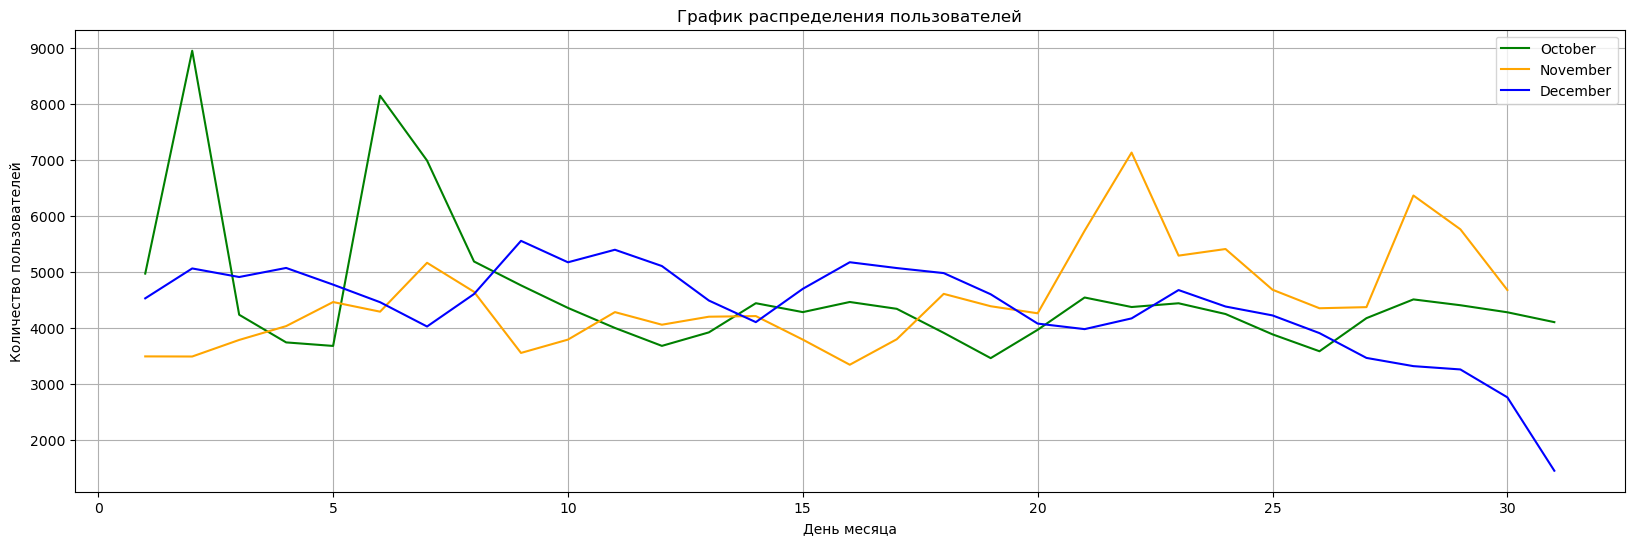

In [10]:
plt.figure(figsize = (20, 6))
plt.title("График распределения пользователей")
plt.xlabel("День месяца")
plt.ylabel("Количество пользователей") 
plt.grid()

plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 10]["day"], 
    unique_users_per_day[unique_users_per_day["month"] == 10]["unique_users_count"],
    label = "October",
    color = "green")


plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 11]["day"], 
    unique_users_per_day[unique_users_per_day["month"] == 11]["unique_users_count"],
    label = "November",
    color = "Orange")


plt.plot(
    unique_users_per_day[unique_users_per_day["month"] == 12]["day"],
    unique_users_per_day[unique_users_per_day["month"] == 12]["unique_users_count"],
    label = "December",
    color = "blue")

plt.legend()
plt.savefig("../images/users_distribution.png")

Узнаем топ 10 самых частых категорий товаров (в датасете они обезличены, есть только id)

In [33]:
category_purchase = df[df["event_type"] == "purchase"]
category_conversion = category_purchase.groupby("category_id")["price"].sum().reset_index(name="purchase_sum").sort_values("purchase_sum", ascending = False)

In [36]:
top_categories = category_conversion.nlargest(10, "purchase_sum")

<Figure size 1500x1500 with 0 Axes>

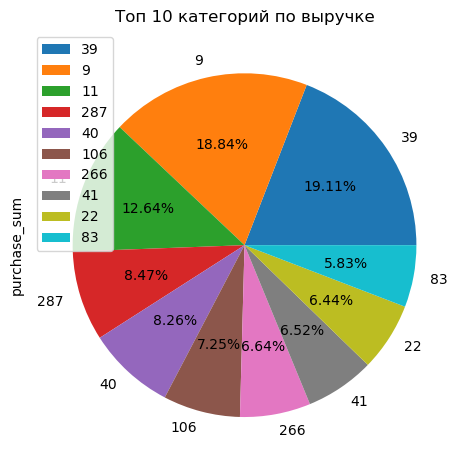

In [47]:
plt.figure(figsize=(15, 15))
top_categories.plot.pie(y = "purchase_sum",autopct='%.2f%%', title='Топ 10 категорий по выручке')
plt.tight_layout()
plt.savefig("../images/category_conversion.png")

Узнаем распределение количества совершенных покупок в зависимости от времени суток

In [42]:
morning_purchase = len(category_purchase[category_purchase["hour"].between(6, 12)])
day_purchase = len(category_purchase[category_purchase["hour"].between(13, 19)])
night_purchase = len(category_purchase[(category_purchase["hour"] >= 20) | (df["hour"] < 6) ])

phase_day = ["morning", "day", "night"]

df_phase_day = pd.Series([morning_purchase, day_purchase, night_purchase], index=phase_day)

C:\Users\s7omb\AppData\Local\Temp\ipykernel_16840\510597287.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  night_purchase = len(category_purchase[(category_purchase["hour"] >= 20) | (df["hour"] < 6) ])


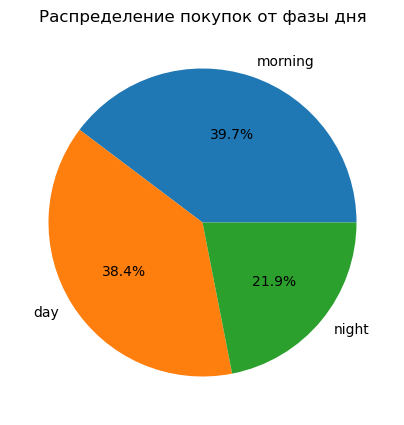

In [43]:
plt.figure(figsize = (5,5))
df_phase_day.plot.pie(y = "count", autopct='%1.1f%%', title = "Распределение покупок от фазы дня")
plt.savefig("../images/purchase_phase_day_distrib.png")

Среднее число сессий до покупки!!!